In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import matplotlib.patches as mpatches

In [58]:
df = pd.read_csv("../data/processed/us_leagues_binomial.csv")

In [62]:
## Adding Necessary Columns

df['log(GOAT)'] = df.apply(lambda row: math.log(int(row['GOAT_Score'])), axis  = 1)

df['log(WOAT)'] = df.apply(lambda row: math.log(int(row['WOAT_Score'])), axis  = 1)

df['formatted_team_name'] = df.apply(lambda row: str(row['Season']) + ' ' + row['Team'], axis = 1)

df['color'] = df.apply(lambda row: "orange" if row['League'] == 'NBA' else 'blue', axis = 1)

In [63]:
df_NBA = df[df["League"] == "NBA"]

df_MLB = df[df["League"] == "MLB"]

In [64]:
df_NBA.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]

,Team,Season,League,GOAT_Score
3133,Chicago Bulls,1995,NBA,1.956068e+12
2850,Chicago Bulls,1996,NBA,8.865848e+09
2528,Oklahoma City Thunder,2024,NBA,1.762217e+09
2365,Golden State Warriors,2016,NBA,3.804222e+08
2604,Los Angeles Lakers,1999,NBA,3.804222e+08
2714,Boston Celtics,1985,NBA,3.804222e+08
2950,Dallas Mavericks,2006,NBA,3.804222e+08
2987,Golden State Warriors,2014,NBA,3.804222e+08
3454,Chicago Bulls,1991,NBA,3.804222e+08
2330,Boston Celtics,2007,NBA,8.881075e+07


In [65]:
df_MLB.nlargest(10, "GOAT_Score")[["Team", "Season", "League", "GOAT_Score"]]

,Team,Season,League,GOAT_Score
1580,Seattle Mariners,2001,MLB,5.449882e+07
454,Cleveland Indians,1954,MLB,4.905777e+07
25,New York Yankees,1927,MLB,1.907257e+07
1484,New York Yankees,1998,MLB,8.867464e+06
90,Philadelphia Athletics,1931,MLB,3.780815e+06
217,New York Yankees,1939,MLB,2.668802e+06
105,New York Yankees,1932,MLB,1.887978e+06
58,Philadelphia Athletics,1929,MLB,8.091980e+05
2199,Los Angeles Dodgers,2022,MLB,7.208491e+05
270,St. Louis Cardinals,1942,MLB,5.903959e+05


In [66]:
top_goat_log = df.nlargest(20, "log(GOAT)")

top_woat_log = df.nlargest(20, "log(WOAT)")

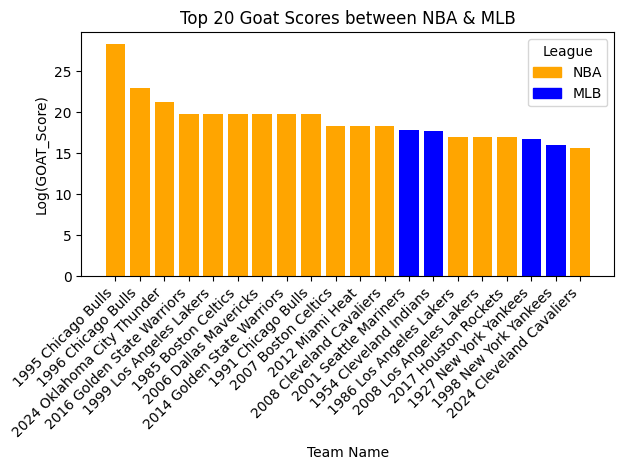

In [67]:
## Plots top 20 GOAT Scores across US Leagues

plt.bar(top_goat_log['formatted_team_name'], top_goat_log['log(GOAT)'], color=top_goat_log['color'])

plt.xlabel("Team Name")
plt.ylabel("Log(GOAT_Score)")
plt.title("Top 20 Goat Scores between NBA & MLB")

plt.xticks(rotation = 45, ha="right")

handles = [
    mpatches.Patch(color="orange", label="NBA"),
    mpatches.Patch(color="blue", label="MLB")
]

plt.legend(handles=handles, title="League")
plt.tight_layout()
plt.show()

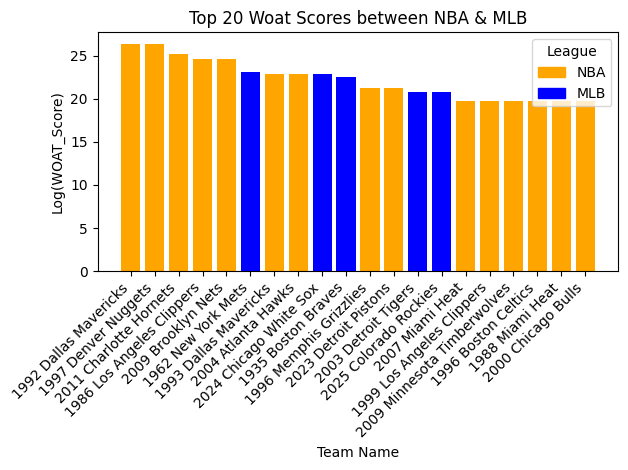

In [68]:
## Plots top 20 WOAT Scores across US Leagues

plt.bar(top_woat_log['formatted_team_name'], top_woat_log['log(WOAT)'], color=top_woat_log['color'])

plt.xlabel("Team Name")
plt.ylabel("Log(WOAT_Score)")
plt.title("Top 20 Woat Scores between NBA & MLB")

plt.xticks(rotation = 45, ha="right")

handles = [
    mpatches.Patch(color="orange", label="NBA"),
    mpatches.Patch(color="blue", label="MLB")
]

plt.legend(handles=handles, title="League")
plt.tight_layout()
plt.show()

In [69]:
## May need to add weights to MLB, since rarities are less likely to occur in a season 2x as long as the NBA.

Text(0.5, 1.0, 'Logarithm of Goat Scores Distribution')

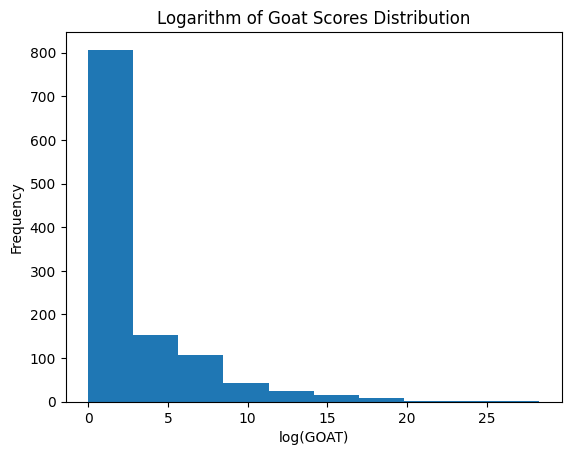

In [ ]:
## Histograms

plt.hist(df_NBA['log(GOAT)'])

plt.ylabel("Frequency")
plt.xlabel("log(GOAT)")
plt.title("Logarithm of NBA Goat Scores Distribution")

Text(0.5, 1.0, 'Logarithm of MLB Goat Scores Distribution')

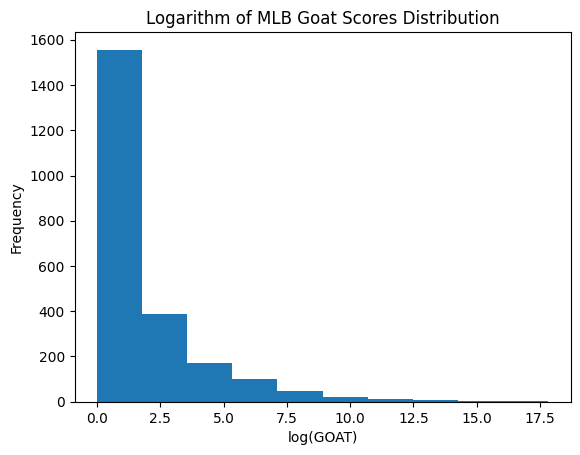

In [78]:
plt.hist(df_MLB['log(GOAT)'])

plt.ylabel("Frequency")
plt.xlabel("log(GOAT)")
plt.title("Logarithm of MLB Goat Scores Distribution")